# Module 7: Python Implementation — CNNs for Sequence Modeling
### Data: Weather_dataset

## 1. Install & Import Libraries

In [113]:
# Install libraries
!pip install tensorflow pandas numpy matplotlib scikit-learn -q
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Weather Dataset

In [114]:
path = "../data/Weather_dataset.csv"
df = pd.read_csv(path) ## Date/Time → only for indexing (optional)Weather → categorical text (ignore for CNN)
print("Dataset Columns:", df.columns.tolist())
print("Dataset Shape:", df.shape)
df.head()

Dataset Columns: ['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather']
Dataset Shape: (8784, 8)


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


## 3. Select Important Features

In [115]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

df["hour"] = df["Date/Time"].dt.hour
df["month"] = df["Date/Time"].dt.month

In [116]:
# Explicitly create a copy to avoid SettingWithCopyWarning
data = df[[
    "Temp_C",
    "Dew Point Temp_C",
    "Rel Hum_%",
    "Wind Speed_km/h",
    "Press_kPa", 
    "hour", 
    "month"
]].copy()
data.head()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Press_kPa,hour,month
0,-1.8,-3.9,86,4,101.24,0,1
1,-1.8,-3.7,87,4,101.24,1,1
2,-1.8,-3.4,89,7,101.26,2,1
3,-1.5,-3.2,88,6,101.27,3,1
4,-1.5,-3.3,88,7,101.23,4,1


In [117]:
data.isna().sum()

Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Press_kPa           0
hour                0
month               0
dtype: int64

In [118]:
## # 3. Handle Missing Values
##data = data.fillna(method="ffill")

In [119]:

data.head()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Press_kPa,hour,month
0,-1.8,-3.9,86,4,101.24,0,1
1,-1.8,-3.7,87,4,101.24,1,1
2,-1.8,-3.4,89,7,101.26,2,1
3,-1.5,-3.2,88,6,101.27,3,1
4,-1.5,-3.3,88,7,101.23,4,1


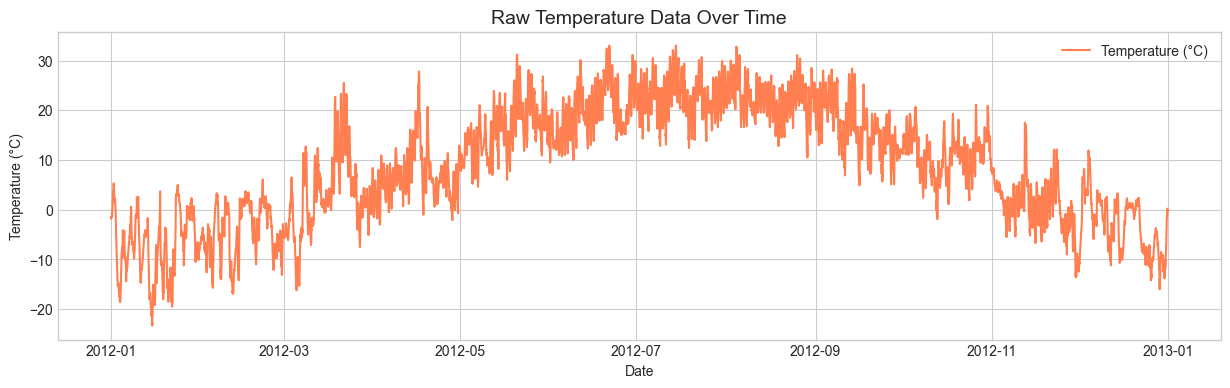

In [120]:
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Temperature Trend
plt.figure(figsize=(15, 4))
plt.plot(df["Date/Time"], data["Temp_C"], color='coral', label='Temperature (°C)')
plt.title("Raw Temperature Data Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

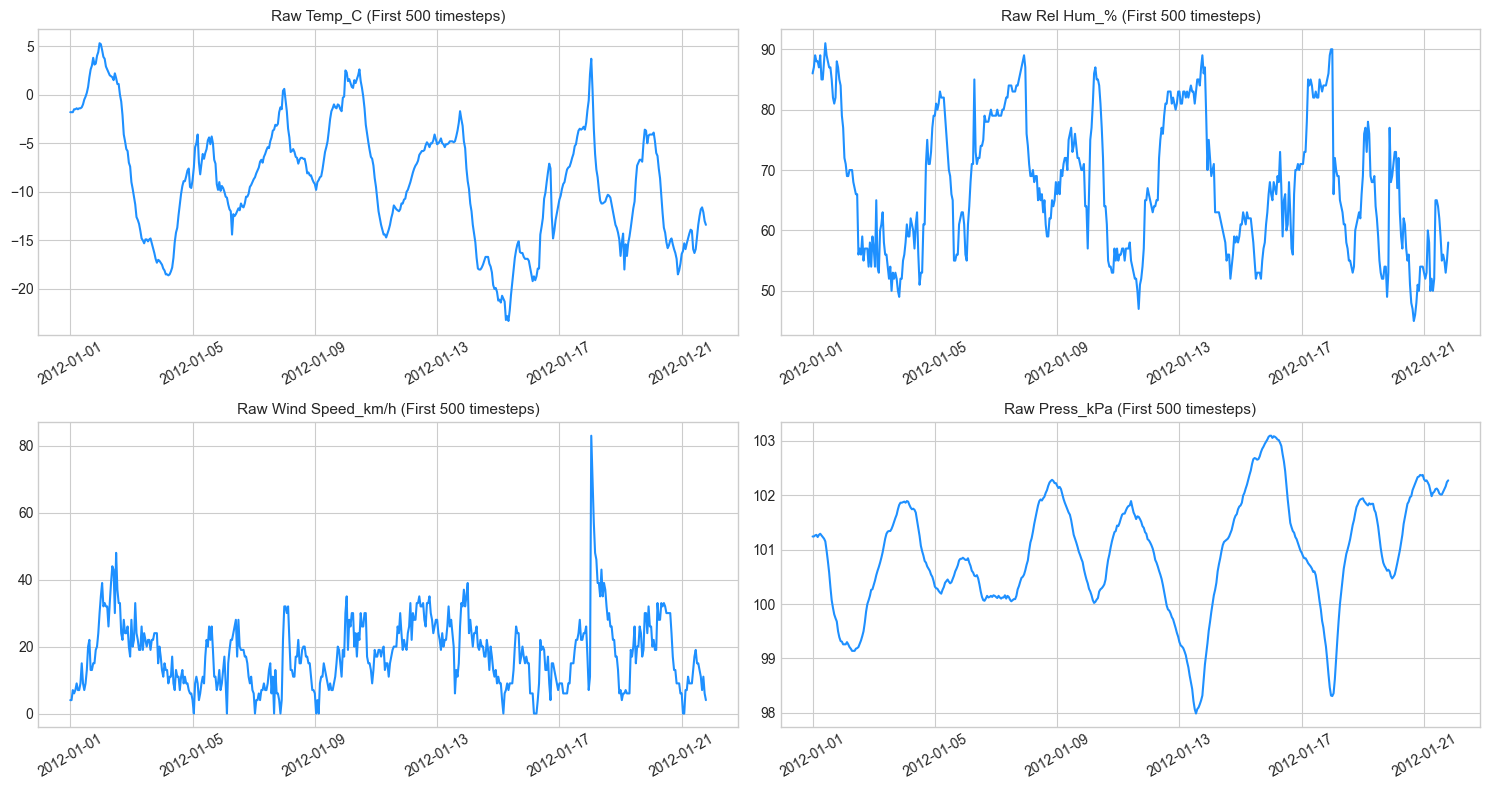

In [121]:
# 2. Grid Plot for Multiple Features (First 500 points for clear scanning)
features_to_plot = ["Temp_C", "Rel Hum_%", "Wind Speed_km/h", "Press_kPa"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].plot(df["Date/Time"].iloc[:500], data[col].iloc[:500], color='dodgerblue')
    axes[i].set_title(f"Raw {col} (First 500 timesteps)", fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

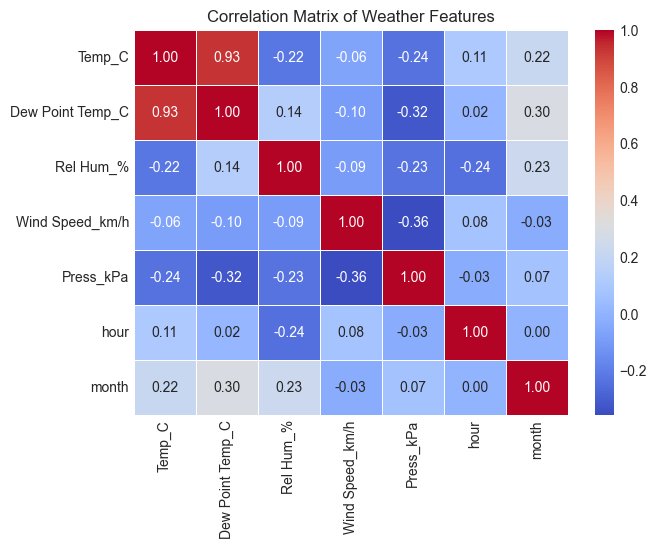

In [122]:
# 3. Feature Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Weather Features", fontsize=12)
plt.show()

## 4. Normalize the Data
We use MinMax Scaling to transform all variables between 0 and 1.

In [123]:
scaler = MinMaxScaler() 
scaled_array = scaler.fit_transform(data) 

# Rebuild DataFrame for clear sequence building
scaled_data = pd.DataFrame(scaled_array, columns=data.columns)
scaled_data.head()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Press_kPa,hour,month
0,0.381883,0.465028,0.829268,0.048193,0.606852,0.000000,0.0
1,0.381883,0.468809,0.841463,0.048193,0.606852,0.043478,0.0
2,0.381883,0.474480,0.865854,0.084337,0.610114,0.086957,0.0
3,0.387211,0.478261,0.853659,0.072289,0.611746,0.130435,0.0
4,0.387211,0.476371,0.853659,0.084337,0.605220,0.173913,0.0


## 5. Create Sequential Windows

Deep learning models for time series require 3D tensors:

[samples,\ timesteps,\ features]

We now create rolling historical windows.

Goal:
- Use previous 24 timesteps
- Predict next temperature value

In [124]:
def create_sequences(data_array, target_column=0, window_size=24):
    X, y = [], []
    for i in range(window_size, len(data_array)):
        X.append(data_array[i-window_size:i])    # Historical window
        y.append(data_array[i, target_column])   # Next target value
    return np.array(X), np.array(y)

## 6.Create sequences

In [125]:
X, y = create_sequences(
    scaled_data.values,
    target_column=0,
    window_size=24
)

# 7. Check Tensor Shapes

In [126]:
print(f"X Tensor Shape (samples, timesteps, features): {X.shape}")
print(f"y Tensor Shape (samples,): {y.shape}")

X Tensor Shape (samples, timesteps, features): (8760, 24, 7)
y Tensor Shape (samples,): (8760,)


# 8. Chronological Train-Test Split

In [127]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (7008, 24, 7)
Testing Shape: (1752, 24, 7)


# 9. Build CNN Model

In [128]:
model = Sequential()

# Explicit Input Layer to define tensor dimensions [timesteps, features]
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# 1D Convolution Layer
model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

# Pooling Layer
model.add(MaxPooling1D(pool_size=2))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(50, activation='relu'))

# Dropout Layer
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1))


# 10. Compile Model

In [129]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 22, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │        35,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,709 (143.39 KB)

 Trainable params: 36,709 (143.39 KB)

 Non-trainable params: 0 (0.00 B)

# 11. Training Configuration with Early Stopping

In [130]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# 12. Train the CNN

In [131]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0155 - mae: 0.0910 - val_loss: 0.0079 - val_mae: 0.0778
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082 - mae: 0.0695 - val_loss: 0.0075 - val_mae: 0.0727
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0068 - mae: 0.0635 - val_loss: 0.0023 - val_mae: 0.0380
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - mae: 0.0578 - val_loss: 0.0030 - val_mae: 0.0440
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049 - mae: 0.0533 - val_loss: 0.0037 - val_mae: 0.0500
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - mae: 0.0496 - val_loss: 0.0020 - val_mae: 0.0357
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - mae: 0.0451 - val_loss: 0.0017 - val_mae: 0.0324
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0031 - mae: 0.0426 - val_loss: 0.0014 - val_mae: 0.0302
Epoch 9/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

# 13. Generate Predictions

In [132]:
predictions = model.predict(X_test)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# 14. Model Performance Loss Curves

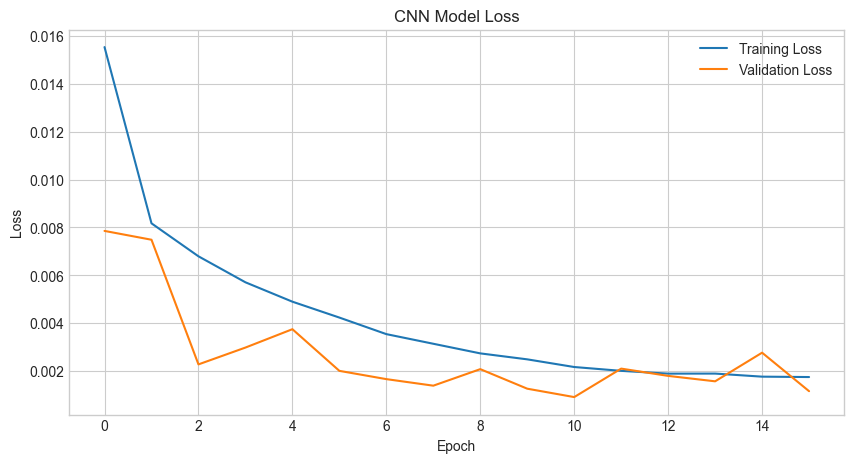

In [133]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# 15. Plot Predictions vs Actual Values

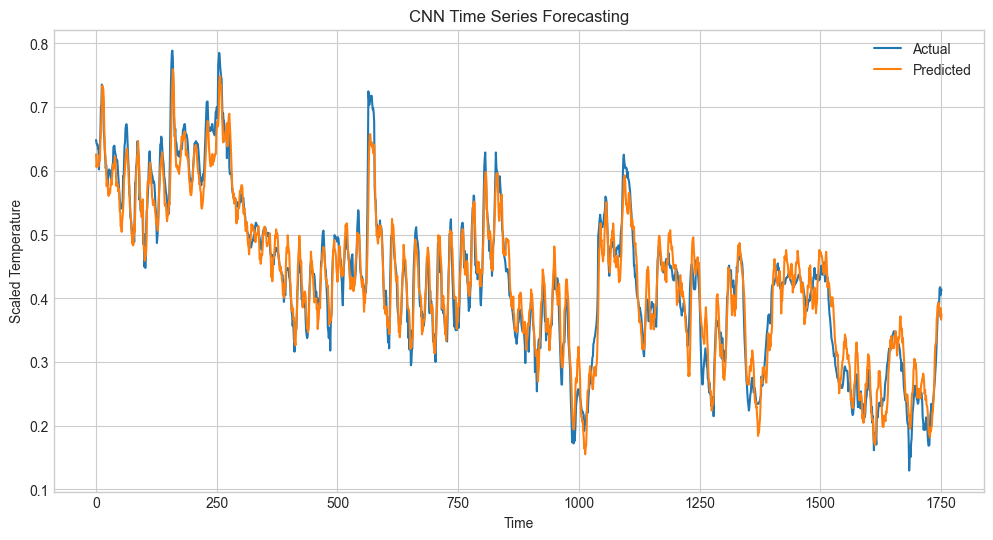

In [134]:
plt.figure(figsize=(12, 6))

plt.plot(y_test, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("CNN Time Series Forecasting")
plt.xlabel("Time")
plt.ylabel("Scaled Temperature")

plt.legend()

plt.show()